In [ ]:
###
    # This code plot the inter-model relationships between permafrost-region mean soil water content (liquid + frozen) 
    # and seasonal soil temperature sensitivity at depths of (a) 1.6 m, (b) 2.4 m, and (c) 3.2 m. 
    # 1. Read soil water content data.
    # 2. Calculate water density (kg/m³) and interpolate onto a uniform vertical grid.
    # 3. Mask grid cells within permafrost regions, then calculate multi-year mean and area-weighted average within the region.
    # 4. Calculate total water content in the upper 1.6 m, 2.4 m, and 3.2 m.
    # 5. Calculate seasonal soil temperature sensitivity for each grid cell, then compute the regional average over permafrost regions.
    # 6. Plot scatter plots.
    # 7. Output: Figure S10.
###

In [1]:
import xarray as xr
import numpy as np
import glob
import matplotlib.pyplot as plt
import warnings
from scipy.interpolate import griddata
import matplotlib.colors as mcolors
import os
warnings.filterwarnings('ignore')

In [2]:
def area_weight_mean(data2D, lat, lon):
    """
    Calculate the area-weighted mean of 2D data, accounting for grid cell areas.
    
    Parameters:
    data2D: ndarray
        Variable for area-weighted averaging, with shape [lat, lon].
    lat: ndarray
        Latitude array, 1D, in degrees.
    lon: ndarray
        Longitude array, 1D, in degrees.
    
    Returns:
    float
        Area-weighted mean of the data.
    """
    # Convert latitude to radians
    rad = np.pi / 180.0
    lat_rad = lat * rad

    # Calculate latitude and longitude resolution
    re = 6371220.0  # Earth radius (in meters)
    dlon = np.abs(lon[1] - lon[0]) * rad  # Longitude resolution (in radians)
    dlat = np.abs(lat[1] - lat[0]) * rad  # Latitude resolution (in radians)

    # Calculate the area of each grid cell
    sin_lat1 = np.sin(lat_rad + dlat / 2)
    sin_lat2 = np.sin(lat_rad - dlat / 2)
    grid_areas = (re ** 2) * dlon * (sin_lat1 - sin_lat2)[:, np.newaxis]  # (lat, lon)

    # Calculate weighted mean
    valid_mask = ~np.isnan(data2D)  # Valid data mask
    weighted_sum = np.nansum(data2D * grid_areas * valid_mask)  # Sum of weighted values
    total_weight = np.nansum(grid_areas * valid_mask)  # Sum of weights

    # If total weight is 0 (all NaN), return NaN
    if total_weight == 0:
        return np.nan

    return weighted_sum / total_weight

In [ ]:
# Create empty list to store area-weighted average of total water for each model
depth_profiles_all_models = []

models = ["CESM2","CESM2-FV2", "CESM2-WACCM",
          "CNRM-CM6-1", "CNRM-ESM2-1",
          "GFDL-ESM4", "NorESM2-LM", "NorESM2-MM", 
          "TaiESM1"
          ]

# Data folder paths
data_folder = "../Data/cmip6_mrsfl/"
data_folder2 = "../Data/cmip6_mrsll/"
probability_file = "../Data/probability_lt_threshold_320.nc"
# Read probability threshold data
ds_prob = xr.open_dataset(probability_file)
ds_prob = ds_prob.sel(lon=slice(0, 186))

# Select grid points with probability_lt_threshold > 0
mask = ds_prob['probability_lt_threshold'] > 0
# Create grid for probability data
lon_prob, lat_prob = np.meshgrid(ds_prob.lon.values, ds_prob.lat.values)

# Loop over each model
for fi, model in enumerate(models):
        
    filepath = glob.glob(data_folder+f"mrsfl_Emon_{model}_*.nc")[0]        
    # Read soil water content data
    ds = xr.open_dataset(filepath)
    ds = ds.sel(lat=slice(45, 77.3), lon=slice(0, 186))

    try:
        # Select time period from 1982 to 2014
        years = np.array([dt.year for dt in ds.time.values])
        year_mask = (years >= 1982) & (years <= 2014)
        ds = ds.isel(time=year_mask)
    except:
        ds = ds.sel(time=slice('1982-01-01', '2014-12-31'))

    filepath2 = glob.glob(data_folder2+f"mrsll_Emon_{model}_*.nc")[0]        
    # Read soil water content data
    ds2 = xr.open_dataset(filepath2)
    ds2 = ds2.sel(lat=slice(45, 77.3), lon=slice(0, 186))

    try:
        # Select time period from 1982 to 2014
        years = np.array([dt.year for dt in ds2.time.values])
        year_mask = (years >= 1982) & (years <= 2014)
        ds2 = ds2.isel(time=year_mask)
    except:
        ds2 = ds2.sel(time=slice('1982-01-01', '2014-12-31'))

    total = (ds['mrsfl'] + ds2['mrsll'])  # shape: (time, depth, lat, lon)

    try:
        depth = ds['depth']
        depth_bnds = ds['depth_bnds']
        thickness = np.empty(len(depth))
        for i in range(len(depth)):
            thickness[i] = depth_bnds.values[i,1]-depth_bnds.values[i,0]         # Calculate thickness
    except:
        try:
            depth = ds['sdepth']
            depth_bnds = ds['sdepth_bounds']
            thickness = np.empty(len(depth))
            for i in range(len(depth)):
                thickness[i] = depth_bnds.values[i,1]-depth_bnds.values[i,0]         # Calculate thickness
        except:
            zhalf_soil = ds['zhalf_soil'].values
            thickness = np.diff(zhalf_soil)         # Calculate thickness
    #print(thickness)
    # Calculate water density (kg/m³)
    density_water_content = total / thickness[None, :, None, None]

    # Create new depth coordinate
    new_depths = np.arange(0.1, 10.1, 0.1)

    # Interpolation
    try:
        density_water_content_interp = density_water_content.interp(
            depth=new_depths, 
            method='linear',
            kwargs={'fill_value': 'extrapolate'}
        )
    except:
        density_water_content_interp = density_water_content.interp(
            sdepth=new_depths, 
            method='linear',
            kwargs={'fill_value': 'extrapolate'}
        )
    # Remove negative values
    density_water_content_interp = density_water_content_interp.clip(min=0)

    # Create grid for soil data
    lon_soil, lat_soil = np.meshgrid(density_water_content_interp.lon.values, density_water_content_interp.lat.values)
    
    # Create grid for probability data
    lon_prob, lat_prob = np.meshgrid(ds_prob.lon.values, ds_prob.lat.values)
    
    # Interpolate mask to soil data grid
    mask_interp = griddata((lon_prob.ravel(), lat_prob.ravel()), 
                            mask.values.ravel(),
                            (lon_soil.ravel(), lat_soil.ravel()), 
                            method='nearest')
    
    mask_interp = mask_interp.reshape(lon_soil.shape).astype(bool)

    # Create mask array with same dimensions as soil data
    mask_da = xr.DataArray(mask_interp, 
                            coords={'lat': density_water_content_interp.lat, 'lon': density_water_content_interp.lon},
                            dims=['lat', 'lon'])

    # Apply mask to filter data
    density_water_masked = density_water_content_interp.where(mask_da, drop=False)

    # Apply land mask
    sftlf = xr.open_dataset(glob.glob(f'../Data/cmip6-fx/sftlf_fx_{model}_*.nc')[0]).sel(lat=slice(45, 77.3), lon=slice(0, 186))['sftlf']

    land_mask_aligned = sftlf.reindex_like(density_water_masked, method='nearest', tolerance=0.01)
    if np.nanmax(land_mask_aligned) == 100:
        land_mask = land_mask_aligned > 50
    else:
        land_mask = land_mask_aligned > 0.5

    density_water_masked = density_water_masked.where(land_mask)
    # Calculate multi-year mean
    mean_yearly_range = density_water_masked.mean(dim='time')

    # ===============================
    # Area weighting (per depth level)
    # ===============================
    lat = mean_yearly_range.lat.values
    lon = mean_yearly_range.lon.values

    depth_profile_weighted = np.zeros(len(new_depths))

    for i in range(len(new_depths)):
        data2D = mean_yearly_range[i,:,:].values  # (lat, lon)
        depth_profile_weighted[i] = area_weight_mean(data2D, lat, lon)

    depth_profiles_all_models.append(depth_profile_weighted)

In [4]:
area_weighted_means16_total2 = []
area_weighted_means24_total2 = []
area_weighted_means32_total2 = []
for k,model in enumerate(models):
    print(model)
    print(np.sum(depth_profiles_all_models[k][2:16])*0.1)
    area_weighted_means16_total2.append(np.sum(depth_profiles_all_models[k][2:16])*0.1)
    area_weighted_means24_total2.append(np.sum(depth_profiles_all_models[k][2:24])*0.1)
    area_weighted_means32_total2.append(np.sum(depth_profiles_all_models[k][2:32])*0.1)

CESM2
432.7980789065439
CESM2-FV2
479.04238242178457
CESM2-WACCM
438.515147680308
CNRM-CM6-1
457.2834941008627
CNRM-ESM2-1
459.26157064888184
GFDL-ESM4
527.1454441108378
NorESM2-LM
470.3938474313069
NorESM2-MM
431.70804405548665
TaiESM1
431.3316777834496


In [ ]:
# Define model list
models = ["CESM2","CESM2-FV2",
          "CESM2-WACCM",
          "CNRM-CM6-1","CNRM-ESM2-1","GFDL-ESM4",
          "NorESM2-LM","NorESM2-MM","TaiESM1"]

# Data folder path
data_folder = "../Data/cmip6_tsl/"

# Create empty lists to store area-weighted means for each model
area_weighted_means32 = []
area_weighted_means24 = []
area_weighted_means16 = []

# Loop over each model
for i, model in enumerate(models):
        
    filepath = glob.glob(data_folder+f"{model}_tsl_monthly_0_3_hd.nc")[0]        
    # Read soil temperature data
    ds_soil = xr.open_dataset(filepath,decode_times=False)
    ds_soil = ds_soil.sel(lat=slice(45, 77.3), lon=slice(0, 186))
    
    # Select grid points with probability_lt_threshold > 0
    mask = ds_prob['probability_lt_threshold'] > 0
    
    # Create grid for soil data
    lon_soil, lat_soil = np.meshgrid(ds_soil.lon.values, ds_soil.lat.values)
    
    # Create grid for probability data
    lon_prob, lat_prob = np.meshgrid(ds_prob.lon.values, ds_prob.lat.values)
    
    # Interpolate mask to soil data grid
    mask_interp = griddata((lon_prob.ravel(), lat_prob.ravel()), 
                            mask.values.ravel(),
                            (lon_soil.ravel(), lat_soil.ravel()), 
                            method='nearest')
    
    mask_interp = mask_interp.reshape(lon_soil.shape).astype(bool)
    
    # Create mask array with same dimensions as soil data
    mask_da = xr.DataArray(mask_interp, 
                            coords={'lat': ds_soil.lat, 'lon': ds_soil.lon},
                            dims=['lat', 'lon'])
    
    # Apply mask to filter data
    ds_soil_masked = ds_soil.where(mask_da, drop=False)
    
    try:
        sftlf = xr.open_dataset(glob.glob(f'/home/jidy/Data/cmip6-fx/sftlf_fx_{model}_*.nc')[0]).sel(lat=slice(45, 77.3), lon=slice(0, 186))['sftlf']
    except:
        sftlf = xr.open_dataset(glob.glob(f'/home/wangjx/Data/cmip6-fx/sftlf_fx_{model}_*.nc')[0]).sel(lat=slice(45, 77.3), lon=slice(0, 186))['sftlf']
    
    if sftlf.lon[0].data == ds_soil_masked.lon[0].data:
        land_mask_aligned = sftlf.reindex_like(ds_soil_masked, method='nearest', 
                                        tolerance=0.01)  # Allow 0.01 degree tolerance
        if np.nanmax(land_mask_aligned)==100:
            land_mask = land_mask_aligned > 50  # Land grid points are True
        else:
            land_mask = land_mask_aligned > 0.5
        ds_soil_masked = ds_soil_masked.where(land_mask)
    else:
        print(model)
    
    # Get depth information
    try:
        depth_values = ds_soil.depth.values
    except:
        depth_values = ds_soil.sdepth.values
    
    # Find index of 0.2m depth layer
    depth_02m_index = None
    for j, depth in enumerate(depth_values):
        if abs(depth - 0.2) < 0.05:  # Allow 0.05m tolerance
            depth_02m_index = j
            break
    
    if depth_02m_index is None:
        print(f"  {model}: 0.2m depth layer not found, skipping this model")
        continue
    
    # Group by year and calculate annual amplitude (max - min) of soil temperature for each year
    n_months = len(ds_soil_masked['time'])
    year_start = 1982
    years = [year_start + i//12 for i in range(n_months)]

    # Add grouping coordinate
    ds_grouped = ds_soil_masked.assign_coords(year_group=('time', years))

    # Calculate annual temperature amplitude for each layer
    yearly_amplitude = ds_grouped['tsl'].groupby('year_group').max(dim='time') - \
                      ds_grouped['tsl'].groupby('year_group').min(dim='time')
    
    # Extract temperature amplitude at 0.2m layer
    try:
        amplitude_02m = yearly_amplitude.isel(depth=depth_02m_index)
    except:
        amplitude_02m = yearly_amplitude.isel(sdepth=depth_02m_index)
    
    # Calculate amplitude ratio relative to 0.2m layer for each layer
    amplitude_ratio = yearly_amplitude / amplitude_02m
    
    # Calculate multi-year mean of amplitude ratio
    mean_amplitude_ratio = amplitude_ratio.mean(dim='year_group')
        
    # Calculate area-weighted mean and store in lists
    area_weighted_means32.append(area_weight_mean(
        mean_amplitude_ratio[-1,:,:].data, 
        mean_amplitude_ratio.lat.data, 
        mean_amplitude_ratio.lon.data
    ))

    area_weighted_means24.append(area_weight_mean(
        mean_amplitude_ratio[23,:,:].data, 
        mean_amplitude_ratio.lat.data, 
        mean_amplitude_ratio.lon.data
    ))

    area_weighted_means16.append(area_weight_mean(
        mean_amplitude_ratio[15,:,:].data, 
        mean_amplitude_ratio.lat.data, 
        mean_amplitude_ratio.lon.data
    ))

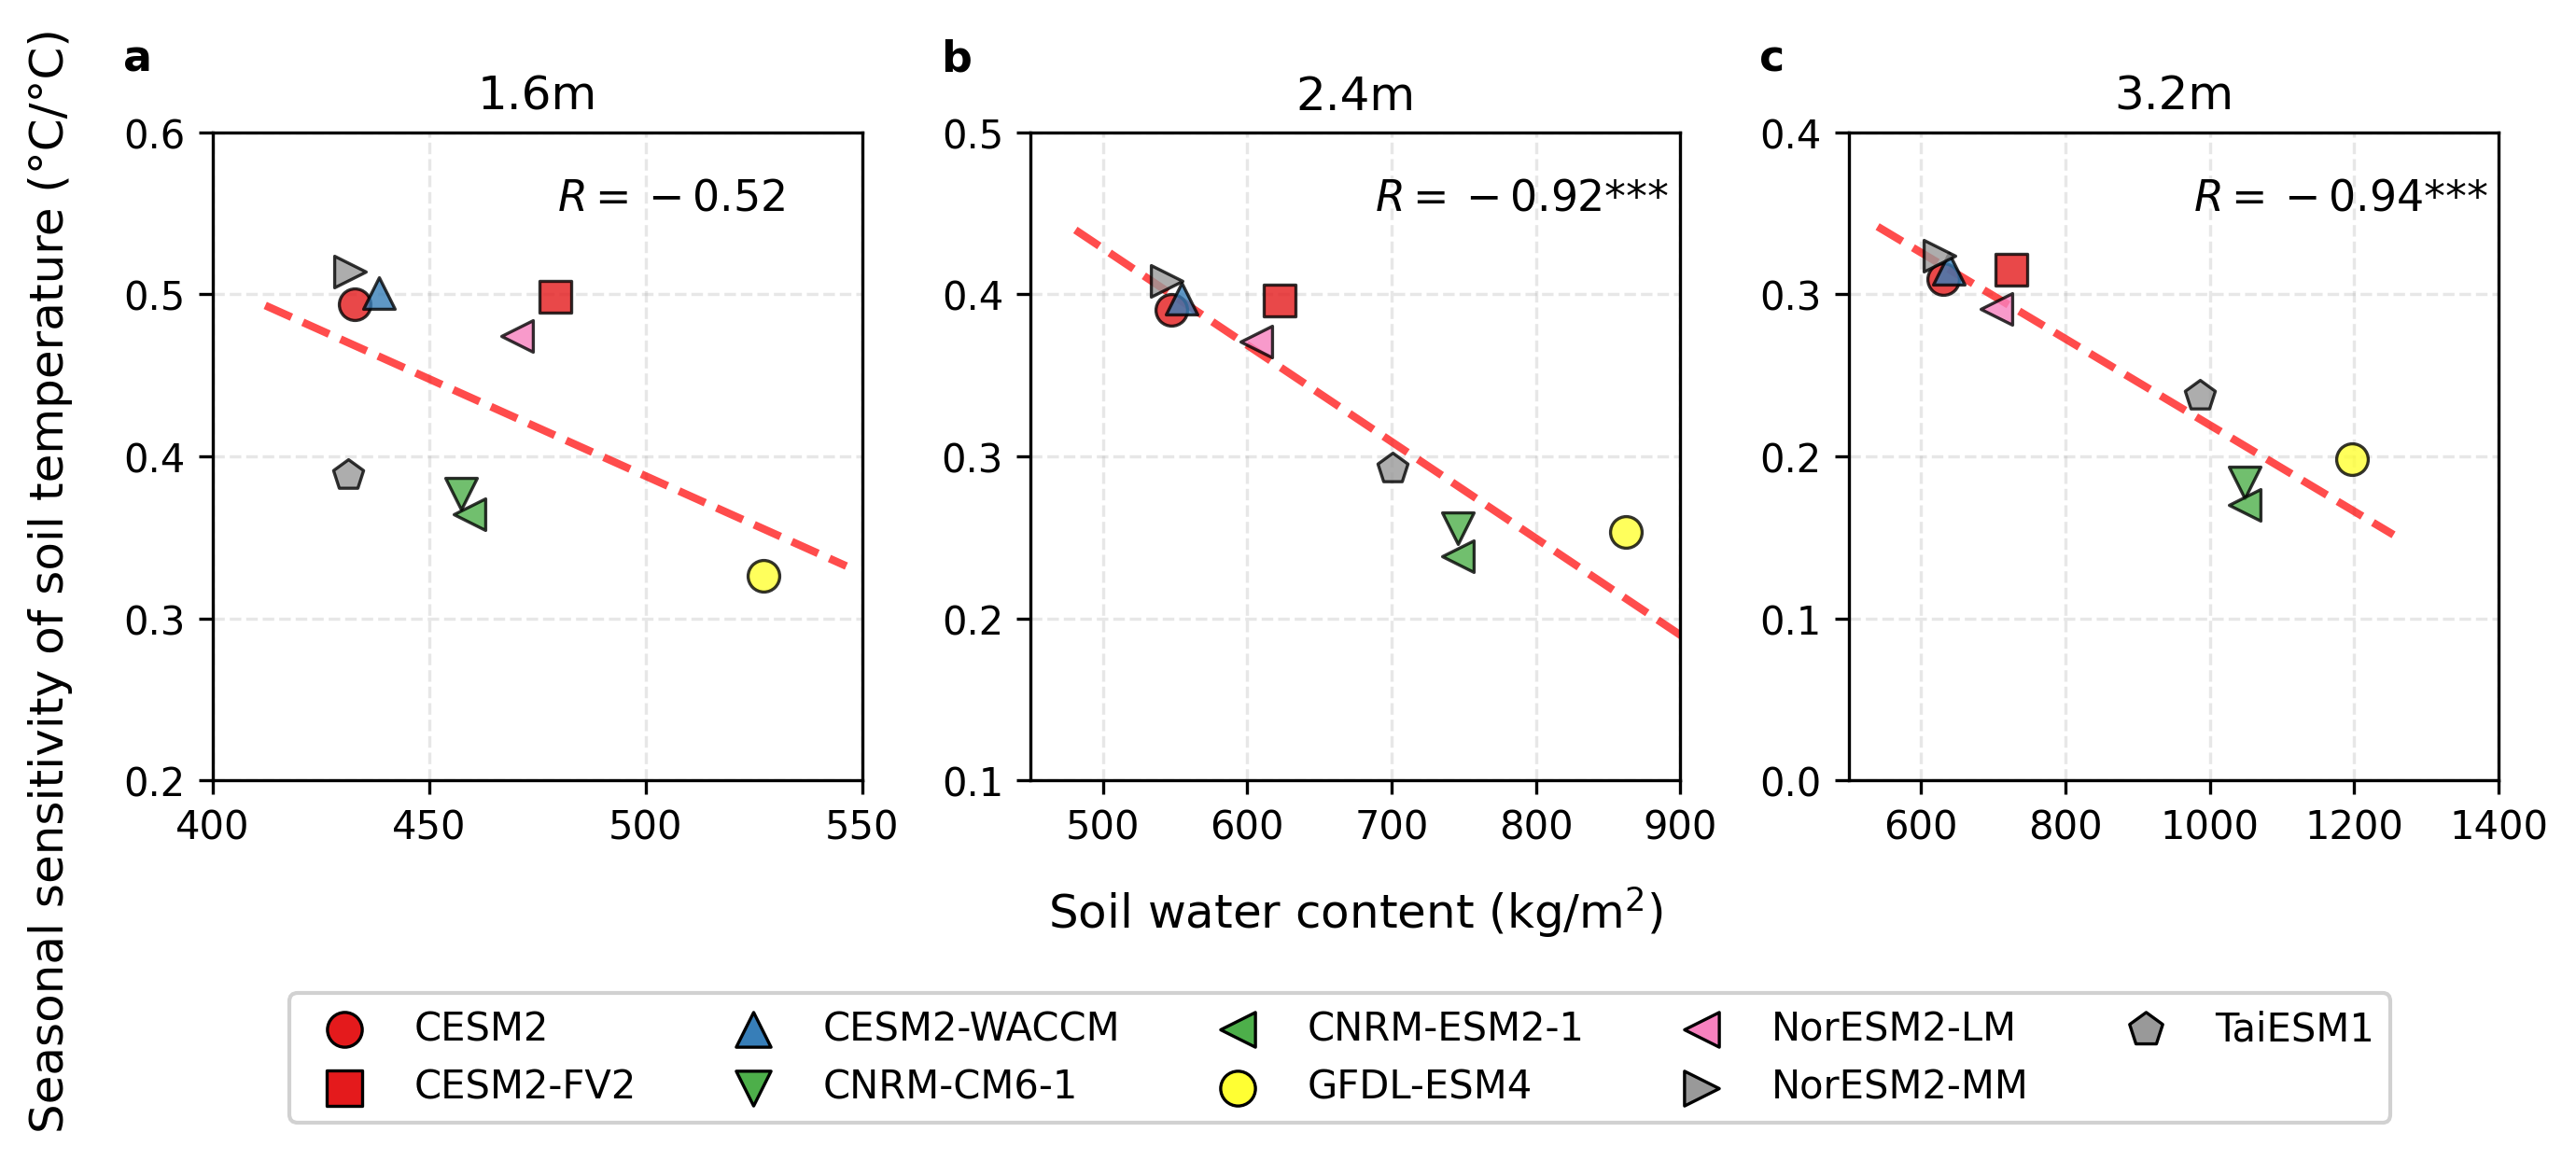

回归分析结果:

1.6m:
  回归方程: y = -0.0012x + 0.9872
  相关系数 R = -0.5176
  p值 = 0.1535
  标准误差 = 0.0007

2.4m:
  回归方程: y = -0.0006x + 0.7266
  相关系数 R = -0.9207
  p值 = 0.0004
  标准误差 = 0.0001

3.2m:
  回归方程: y = -0.0003x + 0.4854
  相关系数 R = -0.9408
  p值 = 0.0002
  标准误差 = 0.0000


In [ ]:
import matplotlib.pyplot as plt
from scipy import stats
import string
from matplotlib.ticker import MultipleLocator 
from matplotlib.font_manager import FontProperties

# Create figure and subplots
fig, axes = plt.subplots(1, 3, figsize=(9.3, 4.3), dpi=300)

# Define data for three depths
depths_data = [
    {
        'title': '1.6m',
        'x_data': area_weighted_means16_total2,  
        'y_data': area_weighted_means16,        
        'ax': axes[0]
    },
    {
        'title': '2.4m', 
        'x_data': area_weighted_means24_total2,  
        'y_data': area_weighted_means24,        
        'ax': axes[1]
    },
    {
        'title': '3.2m',
        'x_data': area_weighted_means32_total2,  
        'y_data': area_weighted_means32,        
        'ax': axes[2]
    }
]

# Define different markers and colors
models_all = ["CESM2", "CESM2-FV2", "CESM2-WACCM", "CNRM-CM6-1-HR", "CNRM-CM6-1", "CNRM-ESM2-1",
             "E3SM-1-1", "FGOALS-f3-L", "FGOALS-g3", "GFDL-CM4", "GFDL-ESM4", "MIROC6",
             "MIROC-ES2L", "MPI-ESM1-2-HR", "MPI-ESM1-2-LR", "NorESM2-LM", "NorESM2-MM", "TaiESM1"]

# Markers and colors for the 18 models
markers_all = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'X']
colors_all = plt.cm.Set1(np.linspace(0, 1, len(models_all)))

# Create a mapping dictionary from model to fixed marker and color
model_style = {}
for i, model in enumerate(models_all):
    model_style[model] = {
        'marker': markers_all[i % len(markers_all)],
        'color': colors_all[i]
    }

# Assign colors and markers to current models based on the mapping dictionary
markers = [model_style[model]['marker'] for model in models]
colors = [model_style[model]['color'] for model in models]
LETTERS = list(string.ascii_lowercase)[:3]

# Plot scatter plots for each depth
for j, depth_info in enumerate(depths_data):
    ax = depth_info['ax']
    x_data = depth_info['x_data']
    y_data = depth_info['y_data']
    
    # Draw scatter points
    for i, model in enumerate(models):
        ax.scatter(x_data[i], y_data[i], 
                  c=[colors[i]], 
                  marker=markers[i % len(markers)],
                  s=66, 
                  alpha=0.8,
                  edgecolors='black', 
                  linewidth=0.8,
                  zorder=3,
                  label=model if depth_info['title'] == '1.6m' else "")  # Only add legend label on the first subplot
    
    # Set axis labels
    if depth_info['title'] == '2.4m':
        ax.set_xlim(450,900)
        ax.set_ylim(0.1, 0.5)
        ax.set_xlabel('Soil water content (kg/m$^{2}$)', 
                  fontsize=12, labelpad=9.5)
    if depth_info['title'] == '1.6m':
        ax.set_xlim(400,550)
        ax.set_ylim(0.2, 0.6)        
        ax.set_ylabel('Seasonal sensitivity of soil temperature (°C/°C)', 
                  fontsize=12, labelpad=13, y=0.31)
    if depth_info['title'] == '3.2m':
        ax.set_xlim(500,1400)
        ax.set_ylim(0.0, 0.4)
    
    ax.yaxis.set_major_locator(MultipleLocator(0.1))   # Major tick labels every 0.1
    # Add grid
    ax.grid(True, alpha=0.3, linestyle='--', zorder=1)
    
    # Add zero reference lines
    ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5, linewidth=0.8, zorder=1)
    ax.axvline(x=0, color='gray', linestyle='-', alpha=0.5, linewidth=0.8, zorder=1)
    
    # Draw regression line (dashed)
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_data, y_data)
    if depth_info['title'] == '3.2m':
        x_fit = np.linspace(min(x_data)-0.15*(max(x_data)-min(x_data)), max(x_data)+0.1*(max(x_data)-min(x_data)), 100)
    else:
        x_fit = np.linspace(min(x_data)-0.2*(max(x_data)-min(x_data)), max(x_data)+0.2*(max(x_data)-min(x_data)), 100)

    y_fit = intercept + slope * x_fit
    ax.plot(x_fit, y_fit, '--', color='red', alpha=0.7, linewidth=2, 
            label=f'R = {r_value:.2f}', zorder=2)
    
    # Display correlation coefficient on the plot
    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    else:
        significance = '' 
        
    ax.text(0.53, 0.88, f'$R = {r_value:.2f}${significance}', 
            transform=ax.transAxes, 
            fontsize=11,
            zorder=4)
    ax.text( -0.138, 1.08, 
        f"{LETTERS[j]}",
        transform=ax.transAxes,
        fontproperties=FontProperties(weight='bold', size=11), 
        verticalalignment='bottom',
        color='black')
    ax.set_title(depth_info['title'], fontsize=12)

# Add legend at the bottom of the figure
fig.legend(handles=[plt.scatter([], [], c=[colors[i]], marker=markers[i % len(markers)], 
                               s=80, edgecolors='black', linewidth=0.8, label=model) 
                   for i, model in enumerate(models)],
          loc='lower center',
          bbox_to_anchor=(0.52, 0.03),
          ncol=5,
          fontsize=10,
          frameon=True,
          #fancybox=True,
          #shadow=True,
          framealpha=0.9)

# Adjust layout to leave space for the bottom legend
plt.tight_layout()
plt.subplots_adjust(bottom=0.33)

plt.show()

# Print detailed statistics
print("回归分析结果:")
for depth_info in depths_data:
    x_data = depth_info['x_data']
    y_data = depth_info['y_data']
    
    if len(x_data) > 1:
        slope, intercept, r_value, p_value, std_err = stats.linregress(x_data, y_data)
        print(f"\n{depth_info['title']}:")
        print(f"  回归方程: y = {slope:.4f}x + {intercept:.4f}")
        print(f"  相关系数 R = {r_value:.4f}")
        print(f"  p值 = {p_value:.4f}")
        print(f"  标准误差 = {std_err:.4f}")

In [8]:
fig.savefig("../Figures/FigureS10.png", bbox_inches='tight',dpi=300)